In [4]:
import pandas as pd

data = pd.read_csv("training_data.csv")

data

,accuracy,wpm,comprehension,label
0,98,165,95,normal
1,96,150,100,normal
2,94,140,90,normal
3,99,175,100,normal
4,97,160,95,normal
5,70,145,90,decoding
6,75,130,85,decoding
7,65,155,92,decoding
8,78,120,88,decoding
9,72,140,80,decoding


In [5]:
data.head()

,accuracy,wpm,comprehension,label
0,98,165,95,normal
1,96,150,100,normal
2,94,140,90,normal
3,99,175,100,normal
4,97,160,95,normal


In [9]:
X = data[
  [
    "accuracy",
    "wpm",
    "comprehension"
  ]
]

y = data["label"]

print("Features (X):")
print(X)

print("\nLabels (y):")
print(y)

Features (X):
    accuracy  wpm  comprehension
0         98  165             95
1         96  150            100
2         94  140             90
3         99  175            100
4         97  160             95
5         70  145             90
6         75  130             85
7         65  155             92
8         78  120             88
9         72  140             80
10        95   55             90
11        92   60             95
12        97   50             88
13        94   65             92
14        96   58             90
15        93  120             45
16        95  110             50
17        90  130             40
18        96  115             35
19        92  125             48

Labels (y):
0            normal
1            normal
2            normal
3            normal
4            normal
5          decoding
6          decoding
7          decoding
8          decoding
9          decoding
10          fluency
11          fluency
12          fluency
13          fluency


In [10]:
print(y.value_counts())

label
normal           5
decoding         5
fluency          5
comprehension    5
Name: count, dtype: int64


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   accuracy       20 non-null     int64
 1   wpm            20 non-null     int64
 2   comprehension  20 non-null     int64
 3   label          20 non-null     str  
dtypes: int64(3), str(1)
memory usage: 772.0 bytes


In [7]:
data["label"].value_counts()

label
normal           5
decoding         5
fluency          5
comprehension    5
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16
Testing samples: 4


In [12]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
  random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [13]:
y_pred = model.predict(X_test)

print("Actual labels:")
print(y_test.values)

print("\nPredicted labels:")
print(y_pred)

Actual labels:
<StringArray>
['decoding', 'comprehension', 'normal', 'fluency']
Length: 4, dtype: str

Predicted labels:
['decoding' 'comprehension' 'normal' 'fluency']


In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 100.00%


In [15]:
from sklearn.metrics import classification_report

print(classification_report(
  y_test,
  y_pred,
  zero_division=0
))

               precision    recall  f1-score   support

comprehension       1.00      1.00      1.00         1
     decoding       1.00      1.00      1.00         1
      fluency       1.00      1.00      1.00         1
       normal       1.00      1.00      1.00         1

     accuracy                           1.00         4
    macro avg       1.00      1.00      1.00         4
 weighted avg       1.00      1.00      1.00         4



In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
  y_test,
  y_pred,
  labels=model.classes_
)

print("Classes:")
print(model.classes_)

print("\nConfusion Matrix:")
print(cm)

Classes:
['comprehension' 'decoding' 'fluency' 'normal']

Confusion Matrix:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]


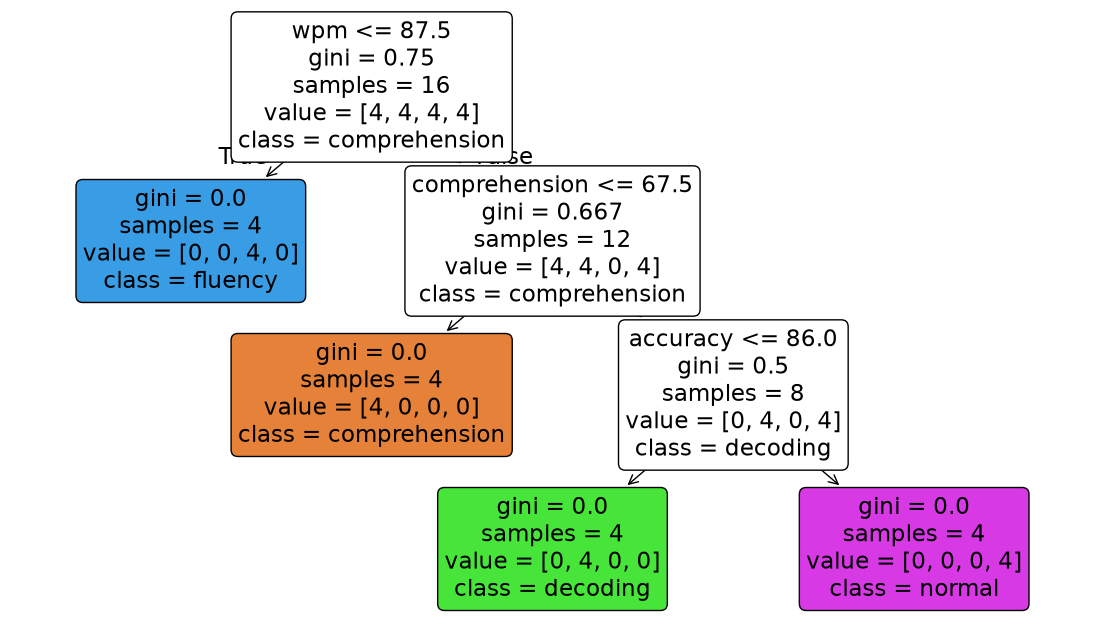

In [17]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

plot_tree(
  model,
  feature_names=[
    "accuracy",
    "wpm",
    "comprehension"
  ],
  class_names=model.classes_,
  filled=True,
  rounded=True
)

plt.show()

In [18]:
new_student = pd.DataFrame([
  {
    "accuracy": 96.3,
    "wpm": 174.5689655172414,
    "comprehension": 100.0
  }
])

prediction = model.predict(new_student)

print("Predicted reading difficulty:", prediction[0])

Predicted reading difficulty: normal
